In [1]:
import argparse
from datetime import datetime
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture as GMM
from utils import *
import numpy as np
import torch
import urllib.request
import os.path

1. Set the hyperparameters of the training

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=1000, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=10, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=100, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

2. Load data

In [3]:
xtrain, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

torch.Size([100, 1, 28, 28])
torch.Size([100, 10])


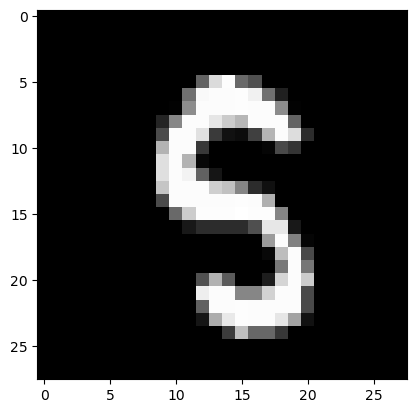

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [4]:
for i, (datax, datay) in enumerate(xtrain):
    datax, datay = datax.to(opt.device), datay.to(opt.device)

    print(datax.shape)
    print(datay.shape)

    # Display image of datax
    plt.imshow(datax[0].cpu().numpy().reshape(28, 28), cmap='gray')
    plt.show()

    print(datay[0].cpu().numpy())
    
    break

In [5]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [6]:
# Define and compute Kernel Matrices, using equation 3 in paper
# This function takes the encoder outputs from two views (X and Y), builds a centered kernel matrix combining both, and then performs kernel PCA to extract the latent variables h and their variances s**.

def kPCA(X, Y):
    a = torch.mm(X, torch.t(X)) + torch.mm(Y, torch.t(Y)) # K = \Phi_X \Phi_X^\top + \Phi_Y \Phi_Y^\top
    nh1 = a.size(0)
    oneN = torch.div(torch.ones(nh1, nh1), nh1).double().to(opt.device)
    a = a - torch.mm(oneN, a) - torch.mm(a, oneN) + torch.mm(torch.mm(oneN, a), oneN)  # centering
    h, s, _ = torch.svd(a, some=False) # Eigendecomposition
    return h[:, :opt.h_dim], s # Select first s principal components, corresponding to the s largest eigenvalues

In [7]:
# Energy function
def rkm_loss(output1, X, output2, Y):
    h, s = kPCA(output1, output2)                   #? 3 - 4: Solve eigendecomposition & select first s principal components
                                                    #?          h = Latent representations, s = Variances (eigenvalues) along those axes

    U = torch.mm(torch.t(output1), h)               #? 10:    𝜙-hat-1(x) ← h using eqaution 5 from paper
    V = torch.mm(torch.t(output2), h)               #? 10:    𝜙-hat-2(y) ← h using eqaution 5 from paper
                                                    #! U = 𝜙1(x)^T h, V = 𝜙2(y)^T h

    x_tilde = net3(torch.mm(h, torch.t(U)))         
    y_tilde = net4(torch.mm(h, torch.t(V)))

    # Costs
    f1 = torch.trace(torch.mm(torch.mm(output1, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output2, V), torch.t(h)))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:opt.h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))))
    recon_loss = torch.nn.MSELoss()
    f4 = recon_loss(x_tilde.view(-1, ipVec_dim), X.view(-1, ipVec_dim)) + recon_loss(y_tilde.view(-1, 10), Y.view(-1, 10))  # reconstruction loss

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + opt.c_accu * f4  # stabilized loss
    return loss

In [8]:
# Initialize Feature/Pre-image maps
net1 = Net1().double().to(opt.device)
net2 = Net2().double().to(opt.device)
net3 = Net3().double().to(opt.device)
net4 = Net4().double().to(opt.device)

In [9]:
params = list(net1.parameters()) + list(net3.parameters()) + list(net2.parameters()) + list(net4.parameters())
optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=0)

In [10]:
l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost
start = datetime.now()

while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    avg_loss = 0
    for i, (datax, datay) in enumerate(xtrain):                         #? Source 1 is the image, Source 2 is the label
        if i < math.ceil(opt.N / opt.mb_size):
            datax, datay = datax.to(opt.device), datay.to(opt.device)   #? 7:      {x, y} ← {Get mini-batch}
            print(datax.shape)
            print(datay.shape)
            output1 = net1(datax)                                       #? 8:      𝜙1(x) ← x     // Get embeddings
            output2 = net2(datay)                                       #? 8:      𝜙y(y) ← y     // Get embeddings
            loss = rkm_loss(output1, datax, output2, datay)             #? 9 - 12: See rkm_loss function

            # Update weights of the networks
            optimizer.zero_grad() # Reset to old gradients
            loss.backward()
            optimizer.step()
            avg_loss += loss.detach().cpu().numpy()
        else:
            break
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)

    dirs.save_checkpoint({
        'epochs': t + 1,
        'net1_state_dict': net1.state_dict(),
        'net3_state_dict': net3.state_dict(),
        'net2_state_dict': net2.state_dict(),
        'net4_state_dict': net4.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)
    print(t, cost)
    t += 1
print('Finished Training in: {}. Lowest cost: {}'.format(str(datetime.now() - start), l_cost))

if os.path.exists('cp/{}'.format(dirs.dircp)):
    sd_mdl = torch.load('cp/{}'.format(dirs.dircp))
    net1.load_state_dict(sd_mdl['net1_state_dict'])
    net3.load_state_dict(sd_mdl['net3_state_dict'])
    net2.load_state_dict(sd_mdl['net2_state_dict'])
    net4.load_state_dict(sd_mdl['net4_state_dict'])

U, V, h, s = final_compute(opt, net1, net2, kPCA)

# Save Model =============
torch.save({'net1': net1,
            'net3': net3,
            'net2': net2,
            'net4': net4,
            'net1_state_dict': net1.state_dict(),
            'net3_state_dict': net3.state_dict(),
            'net2_state_dict': net2.state_dict(),
            'net4_state_dict': net4.state_dict(),
            'h': h,
            'opt': opt, 's': s, 'U': U, 'V': V}, 'out/{}'.format(dirs.dirout))

torch.Size([100, 1, 28, 28])
torch.Size([100, 10])


RuntimeError: Given groups=1, weight of size [32, 3, 4, 4], expected input[100, 1, 28, 28] to have 3 channels, but got 1 channels instead